In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes import (
    TIER1_MINUTES_FEATURES,
    add_minutes_features,
)
from src.models.xgboost_models import (
    DEFAULT_MINUTES_FEATURES,
    XGBoostConfig,
    XGBoostMinutesModel,
)
from src.models.xgboost_models.tuning import tune_minutes

In [2]:
s20 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet')
s21 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet')
s22 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet')
s23 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet')
s24 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet')
s25 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet')
s26 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet')
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)

Number of rows: 176738
Number of columns: 189


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread
23858,2025-26,1641752,Bobi Klintman,Bobi,1610612765,DET,Detroit Pistons,0022500031,2025-11-07T00:00:00,DET @ BKN,...,101.8,99.5,82.92,99,0.343,Regular Season,SF,227.0,10.5,-10.5
10577,2021-22,1630169,Tyrese Haliburton,Tyrese,1610612758,SAC,Sacramento Kings,0022100725,2022-01-26T00:00:00,SAC @ ATL,...,101.9,100.0,83.33,100,0.621,Regular Season,PG,227.0,-11.0,11.0
21274,2022-23,1630700,Dyson Daniels,Dyson,1610612740,NOP,New Orleans Pelicans,0022200217,2022-11-16T00:00:00,NOP vs. CHI,...,100.0,98.5,82.08,99,0.423,Regular Season,PG,226.5,-1.5,-1.5
15921,2019-20,2544,LeBron James,LeBron,1610612747,LAL,Los Angeles Lakers,0021900304,2019-12-03T00:00:00,LAL @ DEN,...,100.8,100.5,83.75,100,0.438,Regular Season,PG,208.0,-2.5,2.5
22059,2025-26,1628404,Josh Hart,Josh,1610612752,NYK,New York Knicks,0022500244,2025-11-17T00:00:00,NYK @ MIA,...,112.1,105.5,87.92,106,0.495,Regular Season,SF,244.5,-1.0,1.0


In [3]:
# adding the features to the whole dataset instead of each season individually to avoid early season features
df = add_minutes_features(df)

TIER1_MINUTES_FEATURES = [
    "min_lag_1",
    "min_mean_3",
    "min_mean_10",
    "min_mean_20",
    "min_ewm_hl_3",
    "min_std_10",
    "start_rate_10",
    "season_rows_prior",
    "season_appearances_prior",
    "season_min_mean",
    "season_min_std",
    "season_start_rate",
    "prior_season_min_mean",
    "prior_season_appearances",
    "current_team_min_mean",
    "current_team_rows_prior",
    "usg_wmean_10",
    "fga_per_min_10",
    "assists_per_min_10",
    "team_pace_mean_10",
    "team_net_rating_mean_10",
    "team_net_rating_season",
    "opp_pace_mean_10",
    "opp_net_rating_mean_10",
    "expected_possessions",
    "team_days_since_prev_game",
    "team_games_prev_3d",
    "player_days_since_appearance",
    "player_appearances_prev_7d",
    "is_home",
    "team_spread_canonical",
    "abs_spread",
    "implied_team_total",
    "min_mean_3_minus_10",
    "min_mean_10_minus_season",
    "start_rate_x_abs_spread",
    "min10_x_expected_possessions"
]

print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of features: {len(TIER1_MINUTES_FEATURES)}")
missing = [col for col in TIER1_MINUTES_FEATURES if col not in df.columns]
print(f"Missing Tier-1 features: {missing or 'none'}")
df[TIER1_MINUTES_FEATURES].head()

Number of rows: 176738
Number of columns: 236
Number of features: 37
Missing Tier-1 features: none


,min_lag_1,min_mean_3,min_mean_10,min_mean_20,min_ewm_hl_3,min_std_10,start_rate_10,season_rows_prior,season_appearances_prior,season_min_mean,...,player_days_since_appearance,player_appearances_prev_7d,is_home,team_spread_canonical,abs_spread,implied_team_total,min_mean_3_minus_10,min_mean_10_minus_season,start_rate_x_abs_spread,min10_x_expected_possessions
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,...,NaN,0.0,0.0,1.5,1.5,110.25,NaN,NaN,NaN,NaN
1,10.233333,10.233333,10.233333,10.233333,10.233333,NaN,0.0,1,1.0,10.233333,...,2.0,1.0,1.0,2.5,2.5,107.00,0.000000,0.0,0.0,1007.983333
2,11.900000,11.066667,11.066667,11.066667,10.577166,1.178511,0.0,2,2.0,11.066667,...,2.0,2.0,1.0,6.5,6.5,107.25,0.000000,0.0,0.0,1135.716667
3,10.716667,10.950000,10.950000,10.950000,10.605945,0.857483,0.0,3,3.0,10.950000,...,1.0,3.0,0.0,8.5,8.5,107.25,0.000000,0.0,0.0,1155.115500
4,18.216667,13.611111,12.766667,12.766667,12.176033,3.700175,0.0,4,4.0,12.766667,...,2.0,4.0,1.0,6.5,6.5,104.25,0.844444,0.0,0.0,1343.595917


In [4]:
appearances = df.loc[df["minutes"].gt(0)].copy()
appearances["game_date"] = pd.to_datetime(appearances["game_date"])

holdout_season = "2025-26"
train = appearances.loc[appearances["season_year"] != holdout_season]
test = appearances.loc[appearances["season_year"] == holdout_season]

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(
    "Train dates: "
    f"{train['game_date'].min().date()} → {train['game_date'].max().date()}"
)
print(
    "Test dates: "
    f"{test['game_date'].min().date()} → {test['game_date'].max().date()}"
)

model = XGBoostMinutesModel(league="nba", feature_columns=TIER1_MINUTES_FEATURES)
model.fit(train)

print(f"Features: {len(model.feature_columns)}")
print(f"Calibration cutoff: {model.regressor.training_cutoff.date()}")
print(f"Trees: {model.regressor.model.n_estimators}")

Train rows: 150,062
Test rows: 26,648
Train dates: 2019-10-22 → 2025-04-13
Test dates: 2025-10-21 → 2026-04-12
Features: 37
Calibration cutoff: 2024-03-18
Trees: 750


In [5]:
import json
import joblib

ARTIFACT_DIR = ROOT / "artifacts" / "models" / "minutes"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

artifact_path = ARTIFACT_DIR / "xgboost_minutes.joblib"
meta_path = ARTIFACT_DIR / "xgboost_minutes_meta.json"

payload = {
    "model": model,
    "feature_columns": list(model.feature_columns),
    "league": model.league,
    "holdout_season": holdout_season,
    "training_cutoff": model.regressor.training_cutoff,
    "n_estimators": int(model.regressor.model.n_estimators),
    "residual_scaling": model.regressor.residual_scaling,
    "objective": model.regressor.objective,
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "n_calibration_residuals": int(
        len(model.regressor.calibration_residuals)
    ),
}
joblib.dump(payload, artifact_path)

meta = {
    "artifact_path": str(artifact_path),
    "league": payload["league"],
    "holdout_season": payload["holdout_season"],
    "training_cutoff": str(payload["training_cutoff"]),
    "n_estimators": payload["n_estimators"],
    "residual_scaling": payload["residual_scaling"],
    "objective": payload["objective"],
    "n_train": payload["n_train"],
    "n_test": payload["n_test"],
    "n_calibration_residuals": payload["n_calibration_residuals"],
    "n_features": len(payload["feature_columns"]),
    "feature_columns": payload["feature_columns"],
}
meta_path.write_text(json.dumps(meta, indent=2))

print(f"Saved model → {artifact_path}")
print(f"Bytes: {artifact_path.stat().st_size:,}")
print(f"Metadata → {meta_path}")
print(f"Features: {meta['n_features']}")
print(f"Calibration residuals: {meta['n_calibration_residuals']:,}")

Saved model → /Users/alexgonzalez/Documents/nba_quant/artifacts/models/minutes/xgboost_minutes.joblib
Bytes: 5,786,223
Metadata → /Users/alexgonzalez/Documents/nba_quant/artifacts/models/minutes/xgboost_minutes_meta.json
Features: 37
Calibration residuals: 140,780


In [6]:
from sklearn.metrics import r2_score

def regression_metrics(frame: pd.DataFrame, split: str) -> dict:
    actual = frame["minutes"].to_numpy(dtype=float)
    predicted = model.predict_mean(frame)
    return {
        "split": split,
        "n": len(frame),
        "r2": r2_score(actual, predicted),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
    }

metrics = pd.DataFrame(
    [
        regression_metrics(train, "train"),
        regression_metrics(test, "test"),
    ]
)
metrics.round(3)

,split,n,r2,mae,rmse
0,train,150062,0.676,4.688,6.106
1,test,26648,0.639,4.733,6.190


In [7]:
from IPython.display import display

cutoff = model.regressor.training_cutoff

chronological = pd.DataFrame(
    [
        regression_metrics(
            train.loc[train["game_date"] < cutoff],
            "development",
        ),
        regression_metrics(
            train.loc[train["game_date"] >= cutoff],
            "calibration",
        ),
        regression_metrics(test, "holdout"),
    ]
)
chronological["notes"] = [
    f"in-sample; dates before {cutoff.date()}",
    "in-sample after refit; used for early stopping",
    "2025-26 out-of-sample",
]

by_season = pd.DataFrame(
    [
        {
            **regression_metrics(
                appearances.loc[appearances["season_year"].eq(season)],
                season,
            ),
            "role": "holdout" if season == holdout_season else "train",
        }
        for season in sorted(appearances["season_year"].unique())
    ]
)

print("Chronological splits")
display(chronological.round(3))
print("By season")
display(by_season.round(3))

Chronological splits


,split,n,r2,mae,rmse,notes
0,development,119055,0.673,4.690,6.104,in-sample; dates before 2024-03-18
1,calibration,31007,0.688,4.678,6.115,in-sample after refit; used for early stopping
2,holdout,26648,0.639,4.733,6.190,2025-26 out-of-sample


By season


,split,n,r2,mae,rmse,role
0,2019-20,22387,0.650,4.670,6.045,train
1,2020-21,23053,0.674,4.642,6.031,train
2,2021-22,26035,0.663,4.769,6.214,train
3,2022-23,25892,0.668,4.747,6.232,train
4,2023-24,26393,0.705,4.656,6.022,train
5,2024-25,26302,0.686,4.637,6.074,train
6,2025-26,26648,0.639,4.733,6.190,holdout


Best features by gain


,rank,feature,gain,gain_share,weight,cover
0,1,min_ewm_hl_3,247969.7969,0.5750,378.0,38640.4258
1,2,min_mean_3,93555.5234,0.2169,378.0,31195.5723
2,3,min_lag_1,15294.5459,0.0355,605.0,32740.9160
3,4,season_min_mean,14280.7988,0.0331,382.0,29344.3066
4,5,min_mean_20,10871.2578,0.0252,223.0,24841.2734
5,6,min_mean_10,10028.6016,0.0233,158.0,22134.5312
6,7,player_days_since_appearance,4696.4917,0.0109,326.0,35412.7969
7,8,current_team_min_mean,3661.4856,0.0085,355.0,34779.9062
8,9,player_appearances_prev_7d,3469.5061,0.0080,129.0,49628.2930
9,10,team_days_since_prev_game,2210.7068,0.0051,277.0,37080.4141


Worst features by gain


,rank,feature,gain,gain_share,weight,cover
0,37,is_home,476.2599,0.0011,89.0,97294.1719
1,36,assists_per_min_10,480.0360,0.0011,163.0,40354.1523
2,35,min_std_10,548.7310,0.0013,309.0,27951.2227
3,34,start_rate_x_abs_spread,551.2206,0.0013,199.0,31061.8086
4,33,prior_season_appearances,554.6432,0.0013,209.0,34732.4023
5,32,current_team_rows_prior,556.9077,0.0013,203.0,35686.0117
6,31,opp_pace_mean_10,570.5031,0.0013,282.0,26132.1562
7,30,fga_per_min_10,574.1469,0.0013,185.0,33667.6602
8,29,expected_possessions,588.3613,0.0014,316.0,39372.2422
9,28,min_mean_3_minus_10,638.5566,0.0015,346.0,24780.3691


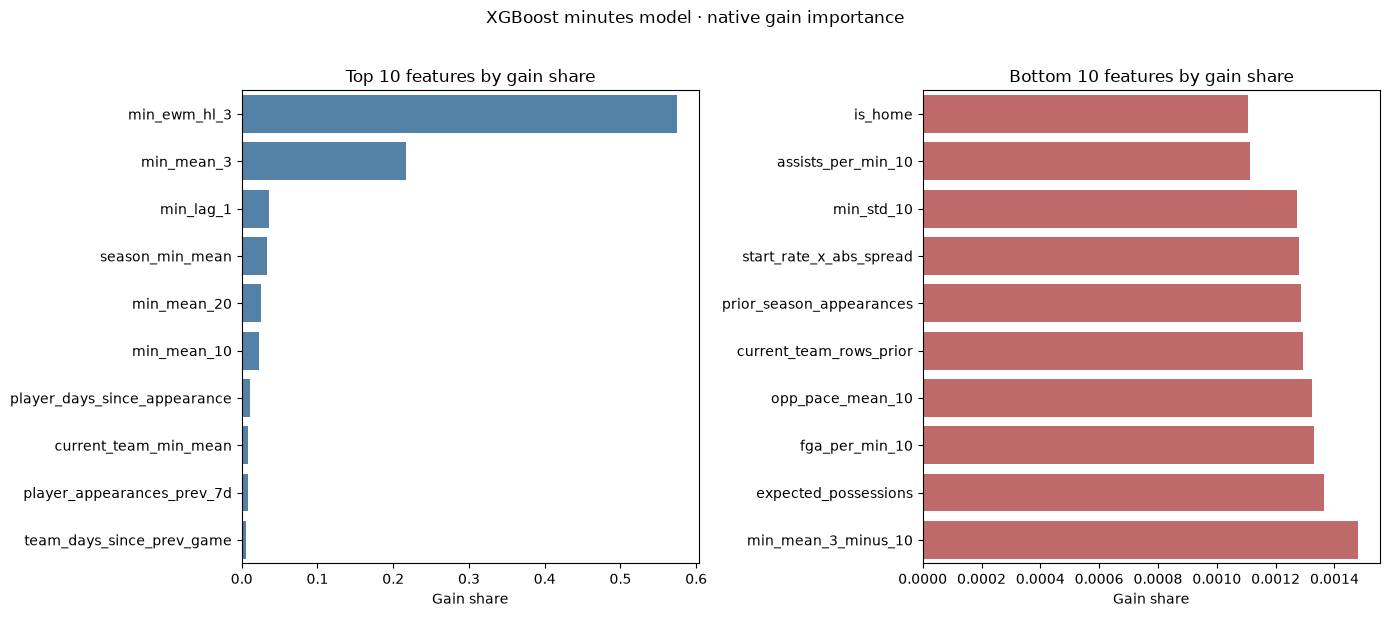

In [8]:
booster = model.regressor.model.get_booster()
importance = pd.DataFrame({"feature": model.feature_columns})
for kind in ("weight", "gain", "cover"):
    scores = booster.get_score(importance_type=kind)
    importance[kind] = importance["feature"].map(scores).fillna(0.0)

importance["gain_share"] = importance["gain"] / importance["gain"].sum()
importance = importance.sort_values("gain", ascending=False).reset_index(drop=True)
importance["rank"] = np.arange(1, len(importance) + 1)

top_n = 10
best = importance.head(top_n)
worst = importance.tail(top_n).iloc[::-1].reset_index(drop=True)

print("Best features by gain")
display(best[["rank", "feature", "gain", "gain_share", "weight", "cover"]].round(4))
print("Worst features by gain")
display(worst[["rank", "feature", "gain", "gain_share", "weight", "cover"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=best,
    y="feature",
    x="gain_share",
    ax=axes[0],
    color="steelblue",
    order=best["feature"],
)
axes[0].set_title("Top 10 features by gain share")
axes[0].set_xlabel("Gain share")
axes[0].set_ylabel("")

sns.barplot(
    data=worst,
    y="feature",
    x="gain_share",
    ax=axes[1],
    color="indianred",
    order=worst["feature"],
)
axes[1].set_title("Bottom 10 features by gain share")
axes[1].set_xlabel("Gain share")
axes[1].set_ylabel("")
fig.suptitle("XGBoost minutes model · native gain importance", y=1.02)
fig.tight_layout()
plt.show()

Holdout baseline MAE: 4.733
Best features by holdout permutation MAE increase


,perm_rank,feature,mae_increase,mae_increase_std,gain_rank,gain_share
0,1,min_ewm_hl_3,1.9681,0.0413,1,0.5750
1,2,min_lag_1,0.3266,0.0084,3,0.0355
2,3,min_mean_3,0.2172,0.0054,2,0.2169
3,4,season_min_mean,0.1675,0.0053,4,0.0331
4,5,team_spread_canonical,0.1558,0.0063,14,0.0041
5,6,player_days_since_appearance,0.1074,0.0031,7,0.0109
6,7,current_team_min_mean,0.0764,0.0035,8,0.0085
7,8,team_net_rating_season,0.0505,0.0035,23,0.0019
8,9,opp_net_rating_mean_10,0.0418,0.0029,24,0.0018
9,10,team_days_since_prev_game,0.0297,0.0019,10,0.0051


Worst features by holdout permutation MAE increase


,perm_rank,feature,mae_increase,mae_increase_std,gain_rank,gain_share
0,37,team_pace_mean_10,0.0015,0.0004,13,0.0043
1,36,min_mean_10,0.0017,0.0007,6,0.0233
2,35,min10_x_expected_possessions,0.0018,0.0005,11,0.0046
3,34,team_games_prev_3d,0.0027,0.0002,22,0.0020
4,33,min_mean_3_minus_10,0.0028,0.0015,28,0.0015
5,32,assists_per_min_10,0.0029,0.0006,36,0.0011
6,31,fga_per_min_10,0.0034,0.0010,30,0.0013
7,30,abs_spread,0.0035,0.0004,27,0.0016
8,29,current_team_rows_prior,0.0036,0.0007,32,0.0013
9,28,min_std_10,0.0036,0.0007,35,0.0013


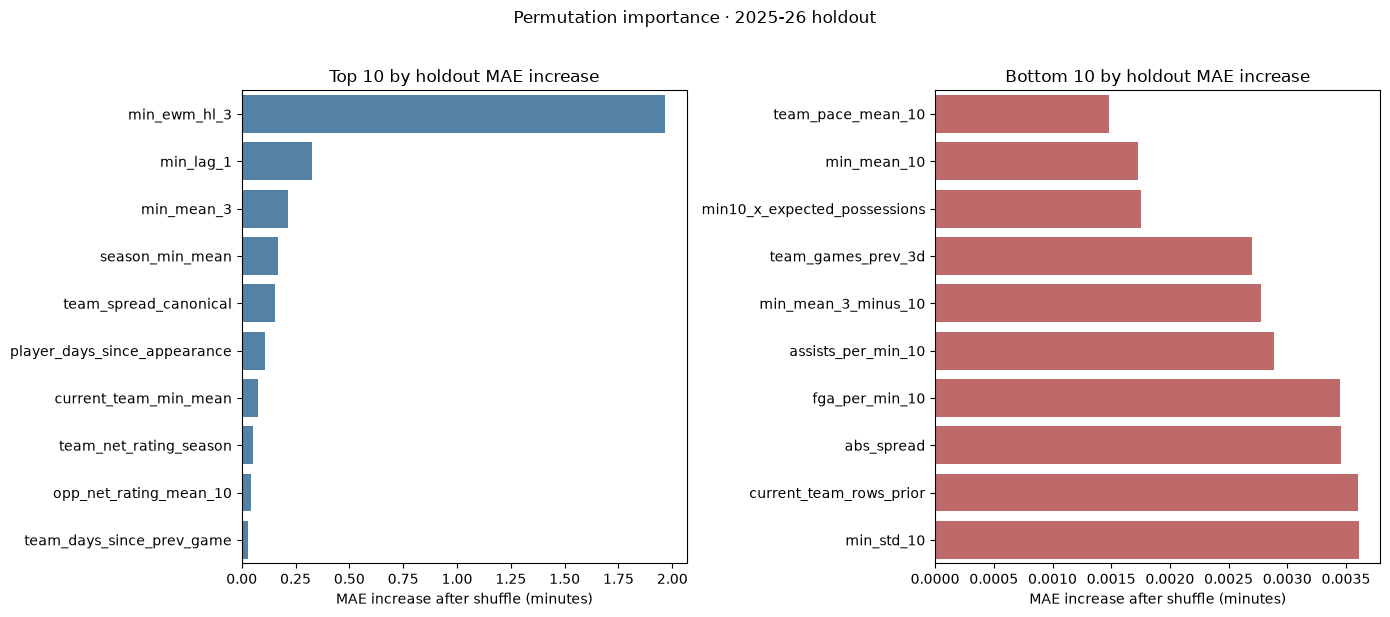

In [9]:
from sklearn.inspection import permutation_importance

X_test = test.loc[:, model.feature_columns].apply(
    pd.to_numeric, errors="coerce"
)
y_test = test["minutes"].to_numpy(dtype=float)
baseline_mae = mean_absolute_error(y_test, model.predict_mean(test))

permutation = permutation_importance(
    model.regressor.model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

perm = pd.DataFrame(
    {
        "feature": model.feature_columns,
        "mae_increase": permutation.importances_mean,
        "mae_increase_std": permutation.importances_std,
    }
)
perm = perm.merge(
    importance[["feature", "gain_share", "rank"]].rename(
        columns={"rank": "gain_rank"}
    ),
    on="feature",
    how="left",
)
perm = perm.sort_values("mae_increase", ascending=False).reset_index(
    drop=True
)
perm["perm_rank"] = np.arange(1, len(perm) + 1)

best_perm = perm.head(top_n)
worst_perm = perm.tail(top_n).iloc[::-1].reset_index(drop=True)
columns = [
    "perm_rank",
    "feature",
    "mae_increase",
    "mae_increase_std",
    "gain_rank",
    "gain_share",
]

print(f"Holdout baseline MAE: {baseline_mae:.3f}")
print("Best features by holdout permutation MAE increase")
display(best_perm[columns].round(4))
print("Worst features by holdout permutation MAE increase")
display(worst_perm[columns].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=best_perm,
    y="feature",
    x="mae_increase",
    ax=axes[0],
    color="steelblue",
    order=best_perm["feature"],
)
axes[0].set_title("Top 10 by holdout MAE increase")
axes[0].set_xlabel("MAE increase after shuffle (minutes)")
axes[0].set_ylabel("")

sns.barplot(
    data=worst_perm,
    y="feature",
    x="mae_increase",
    ax=axes[1],
    color="indianred",
    order=worst_perm["feature"],
)
axes[1].set_title("Bottom 10 by holdout MAE increase")
axes[1].set_xlabel("MAE increase after shuffle (minutes)")
axes[1].set_ylabel("")
fig.suptitle("Permutation importance · 2025-26 holdout", y=1.02)
fig.tight_layout()
plt.show()

In [10]:
dropped = perm.loc[perm["mae_increase"] < 0].sort_values(
    "mae_increase"
)
dropped_features = dropped["feature"].tolist()
reduced_features = [
    column
    for column in TIER1_MINUTES_FEATURES
    if column not in set(dropped_features)
]

print(
    f"Dropped {len(dropped_features)} features with negative "
    "holdout permutation MAE"
)
display(
    dropped[
        ["perm_rank", "feature", "mae_increase", "mae_increase_std"]
    ].round(4)
)
print(
    f"Reduced feature set: {len(reduced_features)} / "
    f"{len(TIER1_MINUTES_FEATURES)} kept"
)
reduced_features

Dropped 0 features with negative holdout permutation MAE


,perm_rank,feature,mae_increase,mae_increase_std


Reduced feature set: 37 / 37 kept


['min_lag_1',
 'min_mean_3',
 'min_mean_10',
 'min_mean_20',
 'min_ewm_hl_3',
 'min_std_10',
 'start_rate_10',
 'season_rows_prior',
 'season_appearances_prior',
 'season_min_mean',
 'season_min_std',
 'season_start_rate',
 'prior_season_min_mean',
 'prior_season_appearances',
 'current_team_min_mean',
 'current_team_rows_prior',
 'usg_wmean_10',
 'fga_per_min_10',
 'assists_per_min_10',
 'team_pace_mean_10',
 'team_net_rating_mean_10',
 'team_net_rating_season',
 'opp_pace_mean_10',
 'opp_net_rating_mean_10',
 'expected_possessions',
 'team_days_since_prev_game',
 'team_games_prev_3d',
 'player_days_since_appearance',
 'player_appearances_prev_7d',
 'is_home',
 'team_spread_canonical',
 'abs_spread',
 'implied_team_total',
 'min_mean_3_minus_10',
 'min_mean_10_minus_season',
 'start_rate_x_abs_spread',
 'min10_x_expected_possessions']

In [11]:
from src.models.evaluation import (
    interval_coverage,
    negative_log_likelihood,
    probability_integral_transform,
)

eval_frame = test.copy()
start_text = (
    eval_frame["start_position"].astype("string").str.strip()
)
eval_frame["actual_starter"] = (
    start_text.notna()
    & start_text.ne("")
    & start_text.ne("nan")
    & start_text.ne("<NA>")
)
eval_frame["has_expected_role"] = eval_frame["start_rate_10"].notna()
eval_frame["expected_starter"] = (
    eval_frame["start_rate_10"] >= 0.5
)
eval_frame["role_shock"] = (
    eval_frame["has_expected_role"]
    & (
        eval_frame["expected_starter"]
        != eval_frame["actual_starter"]
    )
)

actual = eval_frame["minutes"].to_numpy(dtype=float)
samples = model.simulate(eval_frame, simulations=2_000)

print(f"Simulated draws: {samples.shape}")
print(
    "Expected starter rows: "
    f"{int(eval_frame.loc[eval_frame['has_expected_role'], 'expected_starter'].sum()):,}"
)
print(f"Actual starter rows: {int(eval_frame['actual_starter'].sum()):,}")
print(f"Role shock rows: {int(eval_frame['role_shock'].sum()):,}")
print(
    "Missing start_rate_10: "
    f"{int((~eval_frame['has_expected_role']).sum()):,}"
)

Simulated draws: (26648, 2000)
Expected starter rows: 11,945
Actual starter rows: 12,300
Role shock rows: 3,426
Missing start_rate_10: 104


In [12]:
def slice_metrics(
    mask: pd.Series,
    split: str,
) -> dict:
    row_mask = mask.to_numpy()
    slice_samples = samples[row_mask]
    slice_actual = actual[row_mask]
    pit = probability_integral_transform(
        slice_samples,
        slice_actual,
    )
    return {
        "split": split,
        "n": int(row_mask.sum()),
        "coverage_80": interval_coverage(
            slice_samples,
            slice_actual,
        ),
        "pit_mean": float(pit.mean()),
        "pit_std": float(pit.std()),
        "nll": negative_log_likelihood(
            slice_samples,
            slice_actual,
        ),
    }

expected_known = eval_frame["has_expected_role"]
distribution_metrics = pd.DataFrame(
    [
        slice_metrics(
            pd.Series(True, index=eval_frame.index),
            "all",
        ),
        slice_metrics(
            expected_known & eval_frame["expected_starter"],
            "expected_starter",
        ),
        slice_metrics(
            expected_known & ~eval_frame["expected_starter"],
            "expected_bench",
        ),
        slice_metrics(
            eval_frame["actual_starter"],
            "actual_starter",
        ),
        slice_metrics(
            ~eval_frame["actual_starter"],
            "actual_bench",
        ),
        slice_metrics(
            eval_frame["role_shock"],
            "role_shock",
        ),
    ]
)
distribution_metrics.round(3)

,split,n,coverage_80,pit_mean,pit_std,nll
0,all,26648,0.807,0.498,0.285,3.233
1,expected_starter,11945,0.856,0.504,0.265,3.134
2,expected_bench,14599,0.768,0.493,0.299,3.311
3,actual_starter,12300,0.832,0.552,0.270,3.202
4,actual_bench,14348,0.786,0.452,0.289,3.260
5,role_shock,3426,0.695,0.566,0.316,3.530


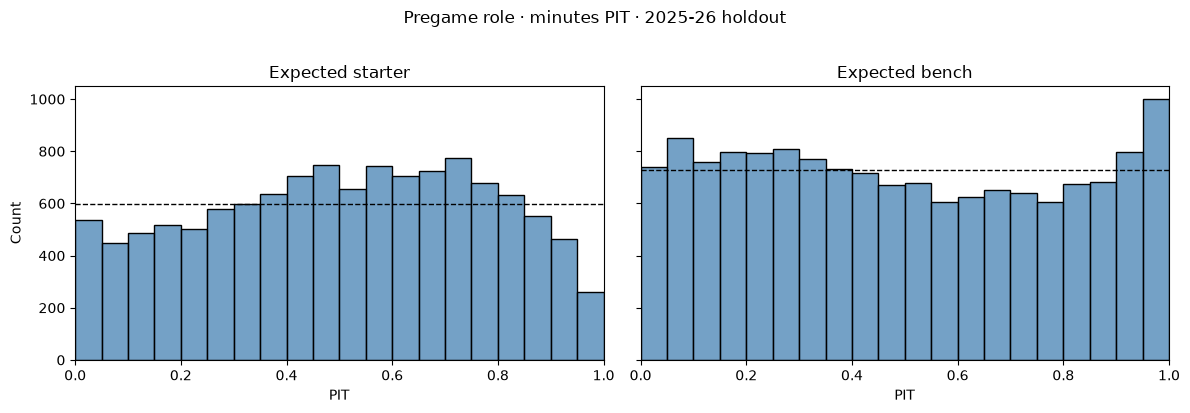

In [13]:
eval_frame["pit"] = probability_integral_transform(
    samples,
    actual,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, title, mask in (
    (
        axes[0],
        "Expected starter",
        eval_frame["has_expected_role"]
        & eval_frame["expected_starter"],
    ),
    (
        axes[1],
        "Expected bench",
        eval_frame["has_expected_role"]
        & ~eval_frame["expected_starter"],
    ),
):
    sns.histplot(
        eval_frame.loc[mask, "pit"],
        bins=20,
        binrange=(0, 1),
        ax=axis,
        color="steelblue",
    )
    axis.axhline(
        len(eval_frame.loc[mask]) / 20,
        color="black",
        linestyle="--",
        linewidth=1,
        label="uniform",
    )
    axis.set_title(title)
    axis.set_xlabel("PIT")
    axis.set_xlim(0, 1)
fig.suptitle(
    "Pregame role · minutes PIT · 2025-26 holdout",
    y=1.02,
)
fig.tight_layout()
plt.show()

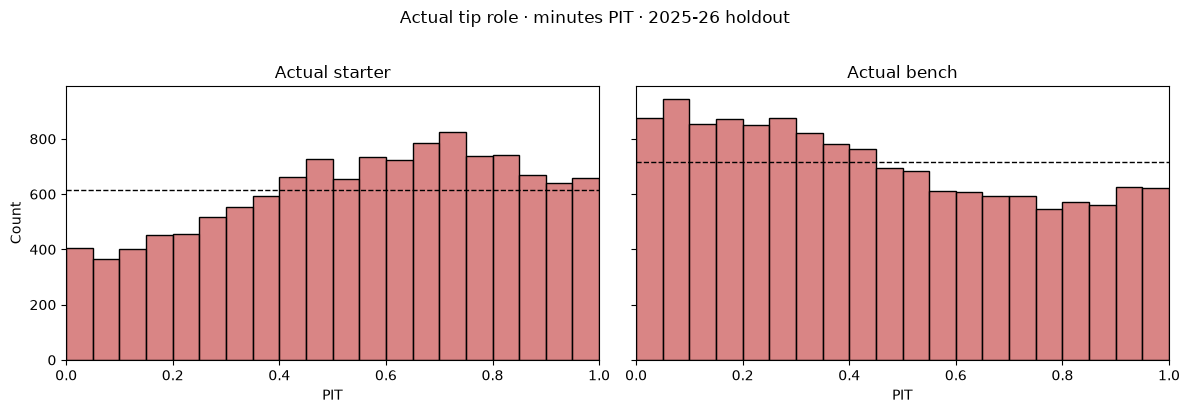

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, title, mask in (
    (axes[0], "Actual starter", eval_frame["actual_starter"]),
    (axes[1], "Actual bench", ~eval_frame["actual_starter"]),
):
    sns.histplot(
        eval_frame.loc[mask, "pit"],
        bins=20,
        binrange=(0, 1),
        ax=axis,
        color="indianred",
    )
    axis.axhline(
        len(eval_frame.loc[mask]) / 20,
        color="black",
        linestyle="--",
        linewidth=1,
        label="uniform",
    )
    axis.set_title(title)
    axis.set_xlabel("PIT")
    axis.set_xlim(0, 1)
fig.suptitle(
    "Actual tip role · minutes PIT · 2025-26 holdout",
    y=1.02,
)
fig.tight_layout()
plt.show()

In [15]:
sat = (
    eval_frame["has_expected_role"]
    & eval_frame["expected_starter"]
    & ~eval_frame["actual_starter"]
)
started = (
    eval_frame["has_expected_role"]
    & ~eval_frame["expected_starter"]
    & eval_frame["actual_starter"]
)

role_shock_metrics = pd.DataFrame(
    [
        slice_metrics(sat, "expected_starter_sat"),
        slice_metrics(started, "expected_bench_started"),
    ]
)
print(
    "Role shock is expected role ≠ actual tip starter. "
    "Coverage collapse or PIT piled at 0/1 means the "
    "volume module does not widen when the rotation moves."
)
role_shock_metrics.round(3)

Role shock is expected role ≠ actual tip starter. Coverage collapse or PIT piled at 0/1 means the volume module does not widen when the rotation moves.


,split,n,coverage_80,pit_mean,pit_std,nll
0,expected_starter_sat,1539,0.774,0.384,0.273,3.311
1,expected_bench_started,1887,0.630,0.714,0.267,3.708
